In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def get_H_data(data_dir):
    X_true = np.load(data_dir + "X_true.npy")
    X_1step = np.load(data_dir + "best_Z.npy")
    X_2step = np.load(data_dir + "best_X_2d.npy")

    H_true = X_true[:, -1]
    H_1step = X_1step[:, -1]
    H_2step = X_2step[:, -1]

    return H_true, H_2step, H_1step

In [3]:
def plot_Hs_minus_median(H_true, H_2s, H_1s):
    _, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes[0].plot(H_true, label="Truth")
    axes[0].plot(H_2s, label="Prediction")
    axes[0].set_title("2 Steps")
    axes[0].set_ylabel("H")
    axes[0].set_xlabel("t")
    axes[0].legend()

    axes[1].plot(H_true, label="Truth")
    axes[1].plot(H_1s, label="Prediction")
    axes[1].set_title("1 Step")
    axes[1].set_ylabel("H")
    axes[1].set_xlabel("t")
    axes[1].legend()

In [4]:
def re(T, P):
    return np.linalg.norm(T - P, ord=2) / np.linalg.norm(T, ord=2) 

def mse(T, P):
    return np.mean((T - P) ** 2)

def calculate_errors(H_true, H_2s, H_1s):
    H_ = H_true - np.median(H_true)
    H_1s_ = H_1s - np.median(H_1s)
    H_2s_ = H_2s - np.median(H_2s)

    re2_obs = re(H_true[:200], H_2s[:200])
    re2_ext = re(H_true[200:], H_2s[200:])
    re1_obs = re(H_true[:200], H_1s[:200])
    re1_ext = re(H_true[200:], H_1s[200:])

    mse2_obs = mse(H_[:200], H_2s_[:200])
    mse2_ext = mse(H_[200:], H_2s_[200:])
    mse1_obs = mse(H_[:200], H_1s_[:200])
    mse1_ext = mse(H_[200:], H_1s_[200:])

    print(f"2 Step RE (Interpolation) = {re2_obs:.4f}")
    print(f"2 Step RE (Extrapolation) = {re2_ext:.4f}")
    print(f"2 Step RE (Total) = {0.5 * (re2_obs + re2_ext):.4f}")
    print("")
    print(f"1 Step RE (Interpolation) = {re1_obs:.4f}")
    print(f"1 Step RE (Extrapolation) = {re1_ext:.4f}")
    print(f"1 Step RE (Total) = {0.5 * (re1_obs + re1_ext):.4f}")
    print("==================================================")
    print(f"2 Step MSE (Interpolation) = {mse2_obs:.5E}")
    print(f"2 Step MSE (Extrapolation) = {mse2_ext:.5E}")
    print(f"2 Step MSE (Total) = {0.5 * (mse2_obs + mse2_ext):.5E}")
    print("")
    print(f"1 Step MSE (Interpolation) = {mse1_obs:.5E}")
    print(f"1 Step MSE (Extrapolation) = {mse1_ext:.5E}")
    print(f"1 Step MSE (Total) = {0.5 * (mse1_obs + mse1_ext):.5E}")

# No Symplectic Integeration

High RE errors are generally coming from the fact that the truth, $H - \bar{H}$ is zero, given that the true $H$ is constant. The reason 2-step RE are lower than their 1-step counterparts is that in the extrapolation period, due that we're explicitly integerating the estimated Hamiltonian, we get a generally more constant $H$. Hence we the median $\bar{H}$ is subtracted, more values become zeros and the RE of 2-step on the extrapolation period is lower. However, the implicit intergeration of the 1-step method results in some energy loss in the extrapolation period, which makes the RE error of the 1-step across the extraplation periiod always close to 1, giveing generally higher RE errors compared to the 2-steps.

## $\alpha = 0$

In [7]:
DATA_DIR = "/home/ubuntu/CGC/200-gaussian-with-data-adjusted-and-re-l2/ms/"

2 Step RE (Interpolation) = 1.9997
2 Step RE (Extrapolation) = 1.9997
2 Step RE (Total) = 1.9997

1 Step RE (Interpolation) = 2.0002
1 Step RE (Extrapolation) = 2.0003
1 Step RE (Total) = 2.0002
2 Step MSE (Interpolation) = 3.14277E-10
2 Step MSE (Extrapolation) = 1.27118E-13
2 Step MSE (Total) = 1.57202E-10

1 Step MSE (Interpolation) = 3.20568E-09
1 Step MSE (Extrapolation) = 2.58473E-13
1 Step MSE (Total) = 1.60297E-09


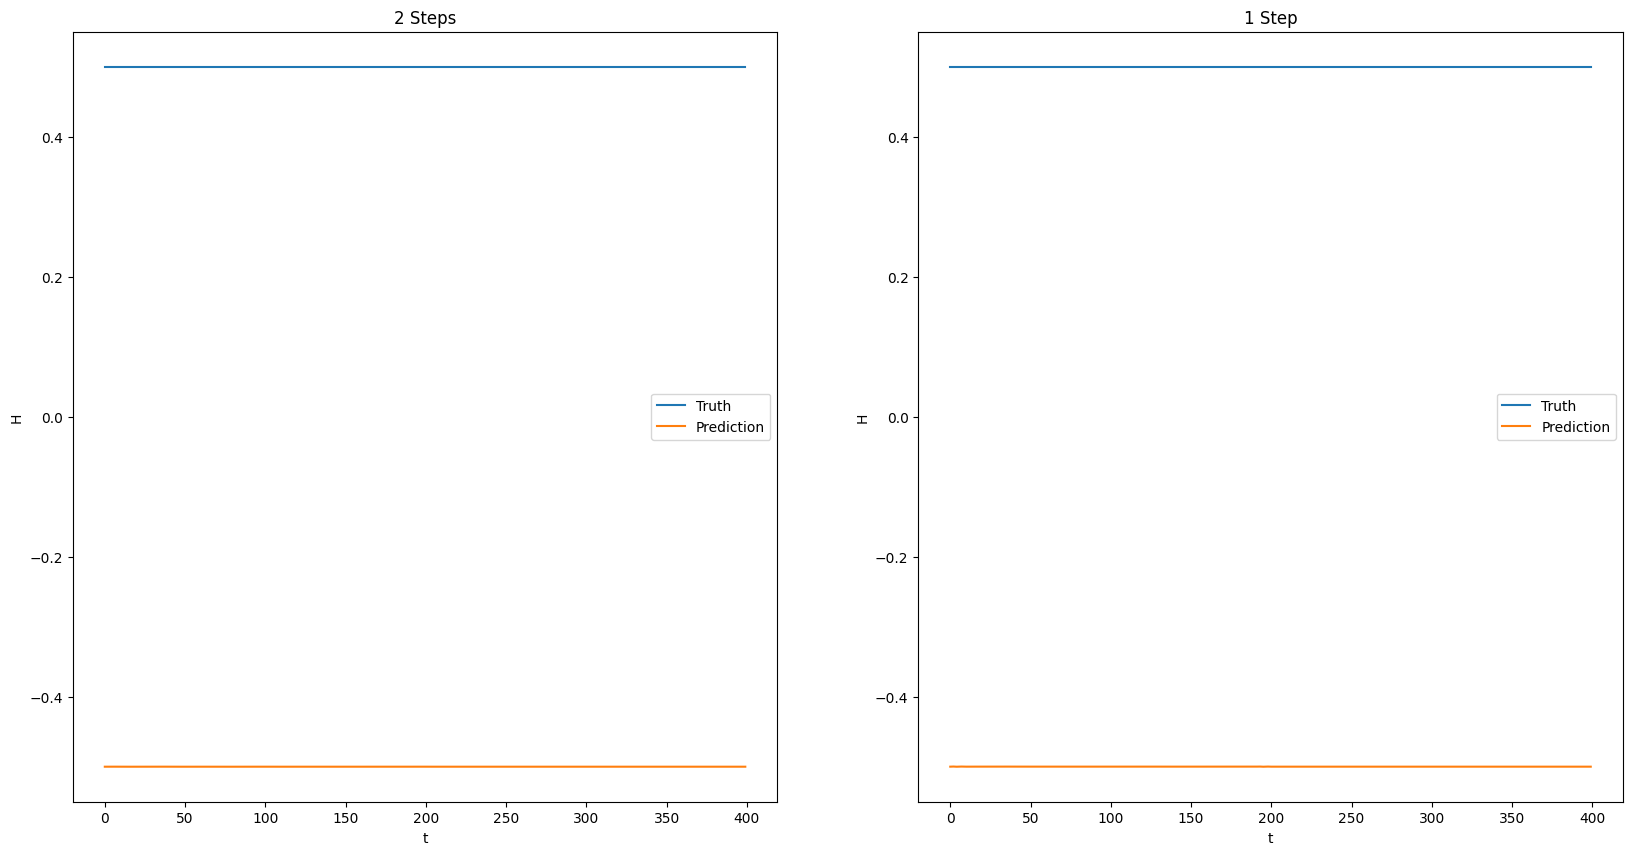

In [8]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.0-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.5$

2 Step RE (Interpolation) = 1.9867
2 Step RE (Extrapolation) = 1.9870
2 Step RE (Total) = 1.9869

1 Step RE (Interpolation) = 2.0001
1 Step RE (Extrapolation) = 2.0002
1 Step RE (Total) = 2.0002
2 Step MSE (Interpolation) = 7.38972E-08
2 Step MSE (Extrapolation) = 3.05624E-13
2 Step MSE (Total) = 3.69488E-08

1 Step MSE (Interpolation) = 8.92658E-09
1 Step MSE (Extrapolation) = 2.06008E-13
1 Step MSE (Total) = 4.46340E-09


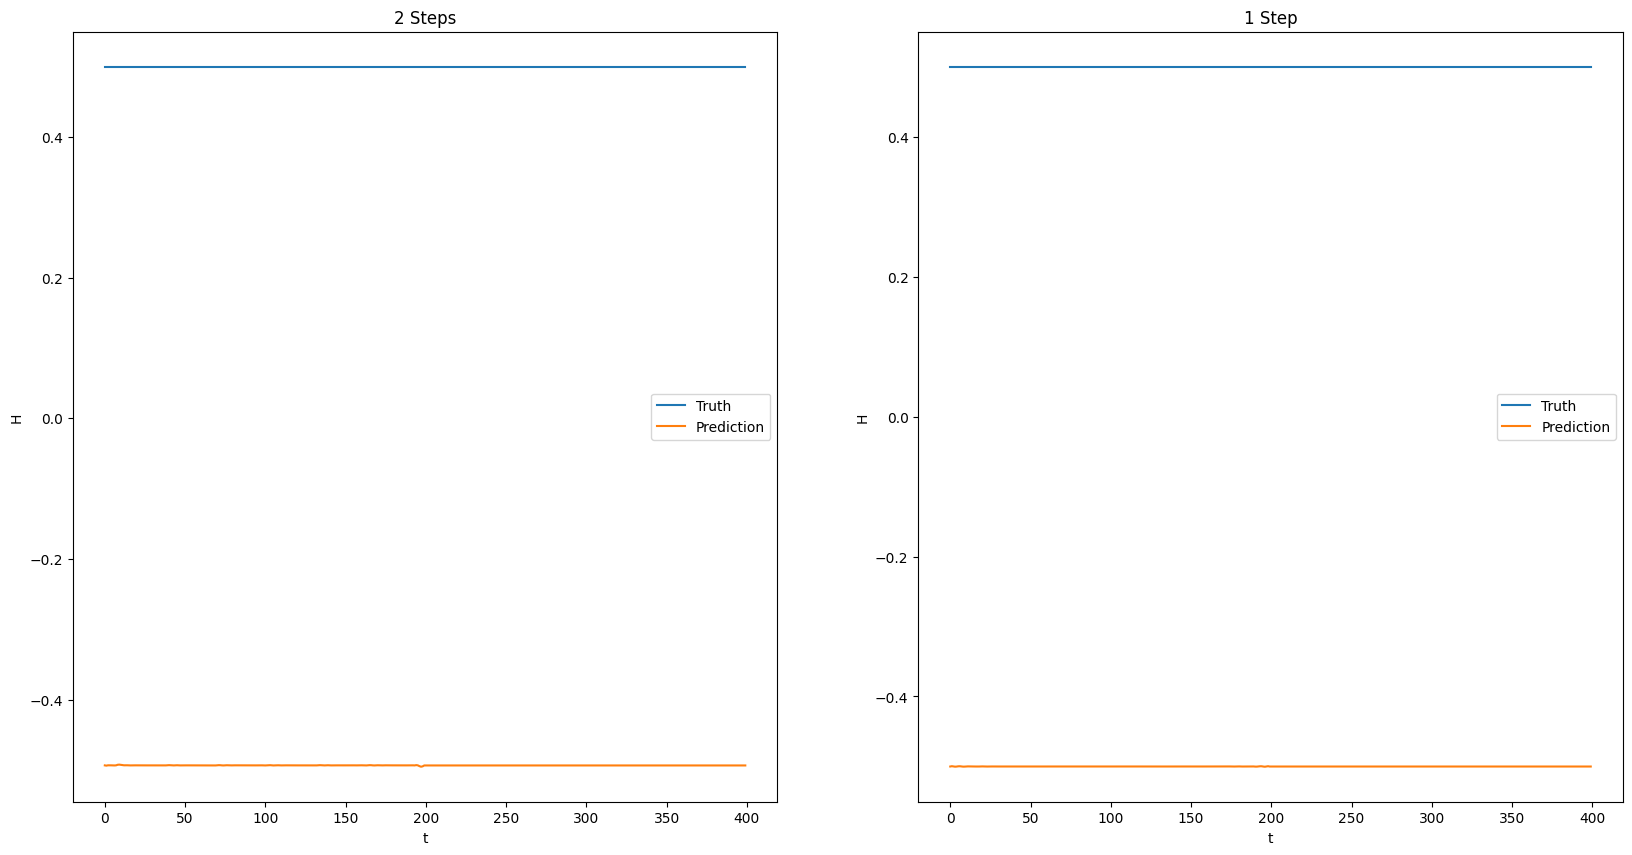

In [19]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.5-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.6$

2 Step RE (Interpolation) = 0.9945
2 Step RE (Extrapolation) = 0.8813
2 Step RE (Total) = 0.9379

1 Step RE (Interpolation) = 1.0000
1 Step RE (Extrapolation) = 1.0000
1 Step RE (Total) = 1.0000
2 Step MSE (Interpolation) = 2.38786E-05
2 Step MSE (Extrapolation) = 2.53900E-13
2 Step MSE (Total) = 1.19393E-05

1 Step MSE (Interpolation) = 2.86716E-07
1 Step MSE (Extrapolation) = 1.57821E-03
1 Step MSE (Total) = 7.89250E-04


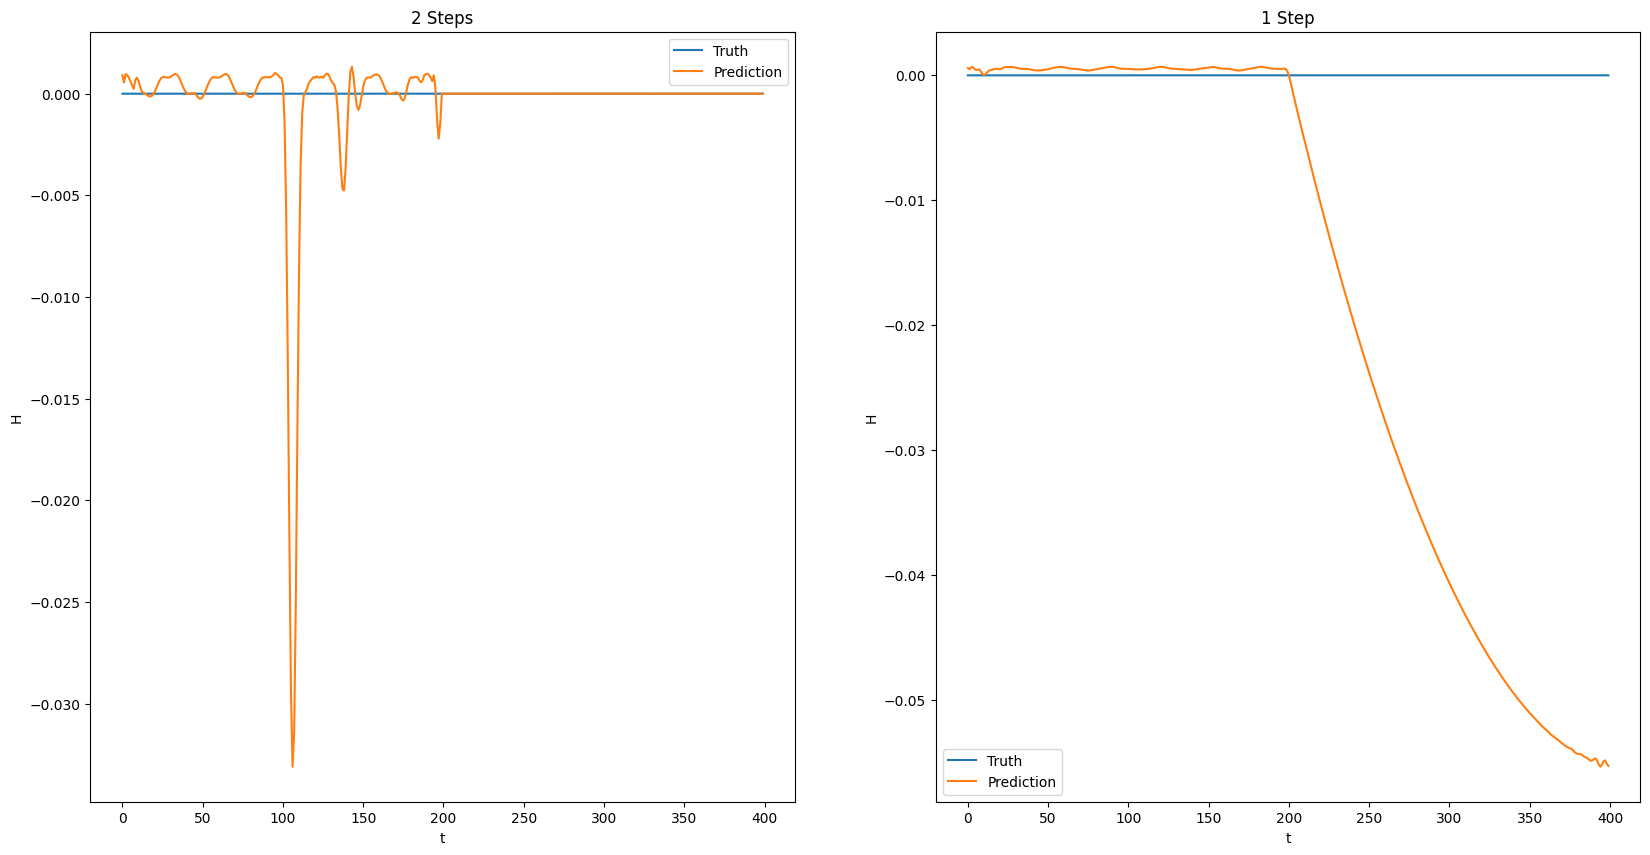

In [24]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.6-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.7$

2 Step RE (Interpolation) = 0.9997
2 Step RE (Extrapolation) = 0.4591
2 Step RE (Total) = 0.7294

1 Step RE (Interpolation) = 0.9998
1 Step RE (Extrapolation) = 1.0000
1 Step RE (Total) = 0.9999
2 Step MSE (Interpolation) = 1.67950E-03
2 Step MSE (Extrapolation) = 3.05785E-14
2 Step MSE (Total) = 8.39752E-04

1 Step MSE (Interpolation) = 5.40576E-08
1 Step MSE (Extrapolation) = 2.14753E-05
1 Step MSE (Total) = 1.07647E-05


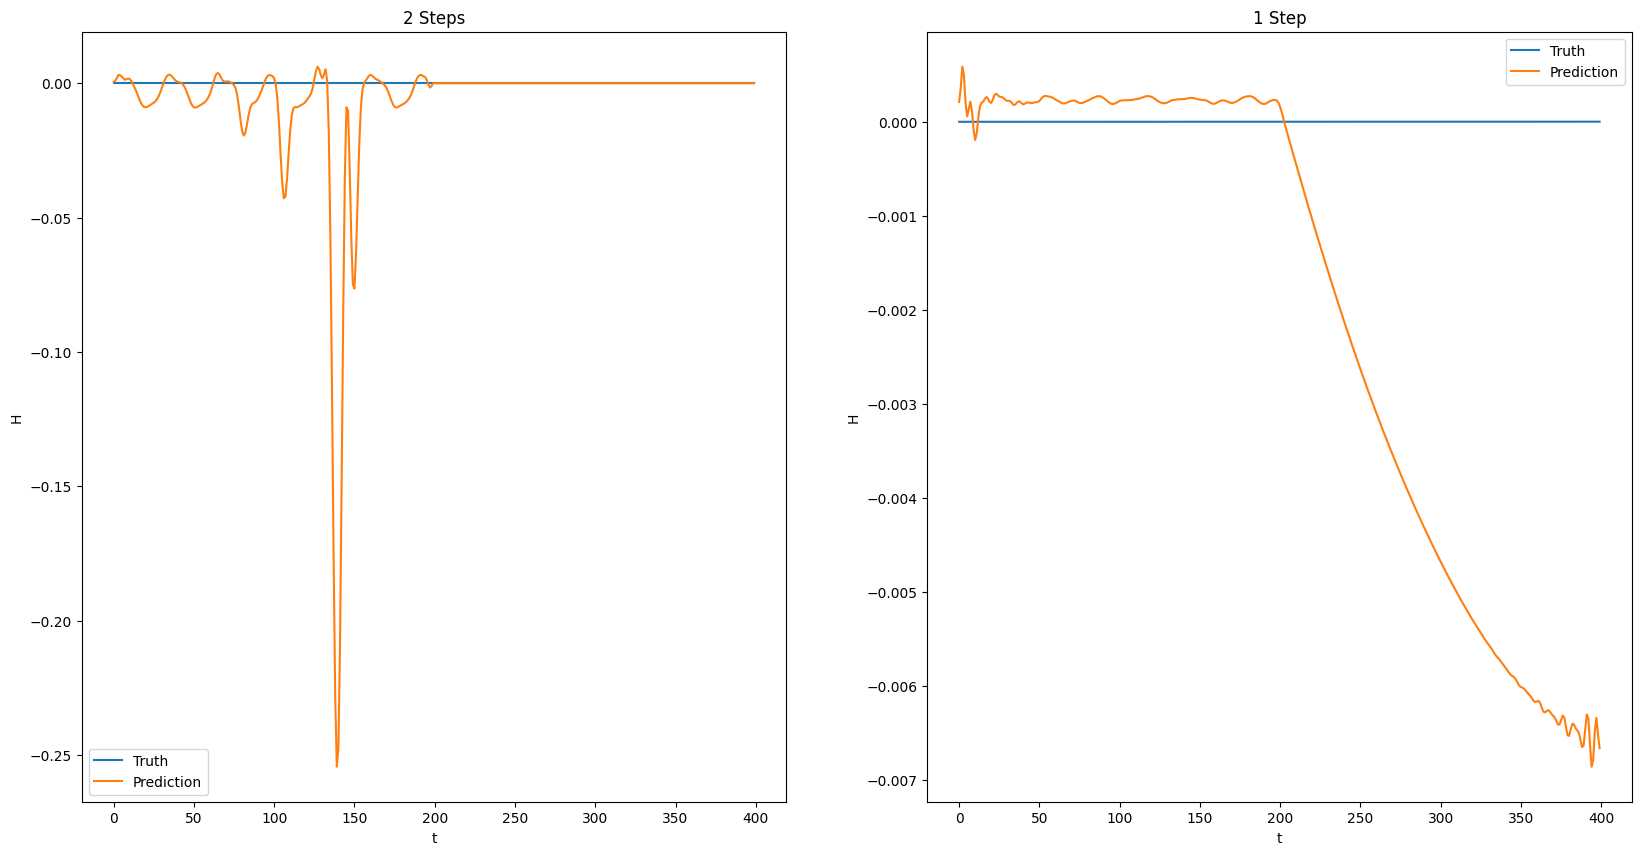

In [25]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.7-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.8$

2 Step RE (Interpolation) = 0.9999
2 Step RE (Extrapolation) = 0.7968
2 Step RE (Total) = 0.8983

1 Step RE (Interpolation) = 0.9887
1 Step RE (Extrapolation) = 0.9995
1 Step RE (Total) = 0.9941
2 Step MSE (Interpolation) = 2.61658E-02
2 Step MSE (Extrapolation) = 9.67955E-14
2 Step MSE (Total) = 1.30829E-02

1 Step MSE (Interpolation) = 7.77051E-09
1 Step MSE (Extrapolation) = 9.98038E-08
1 Step MSE (Total) = 5.37872E-08


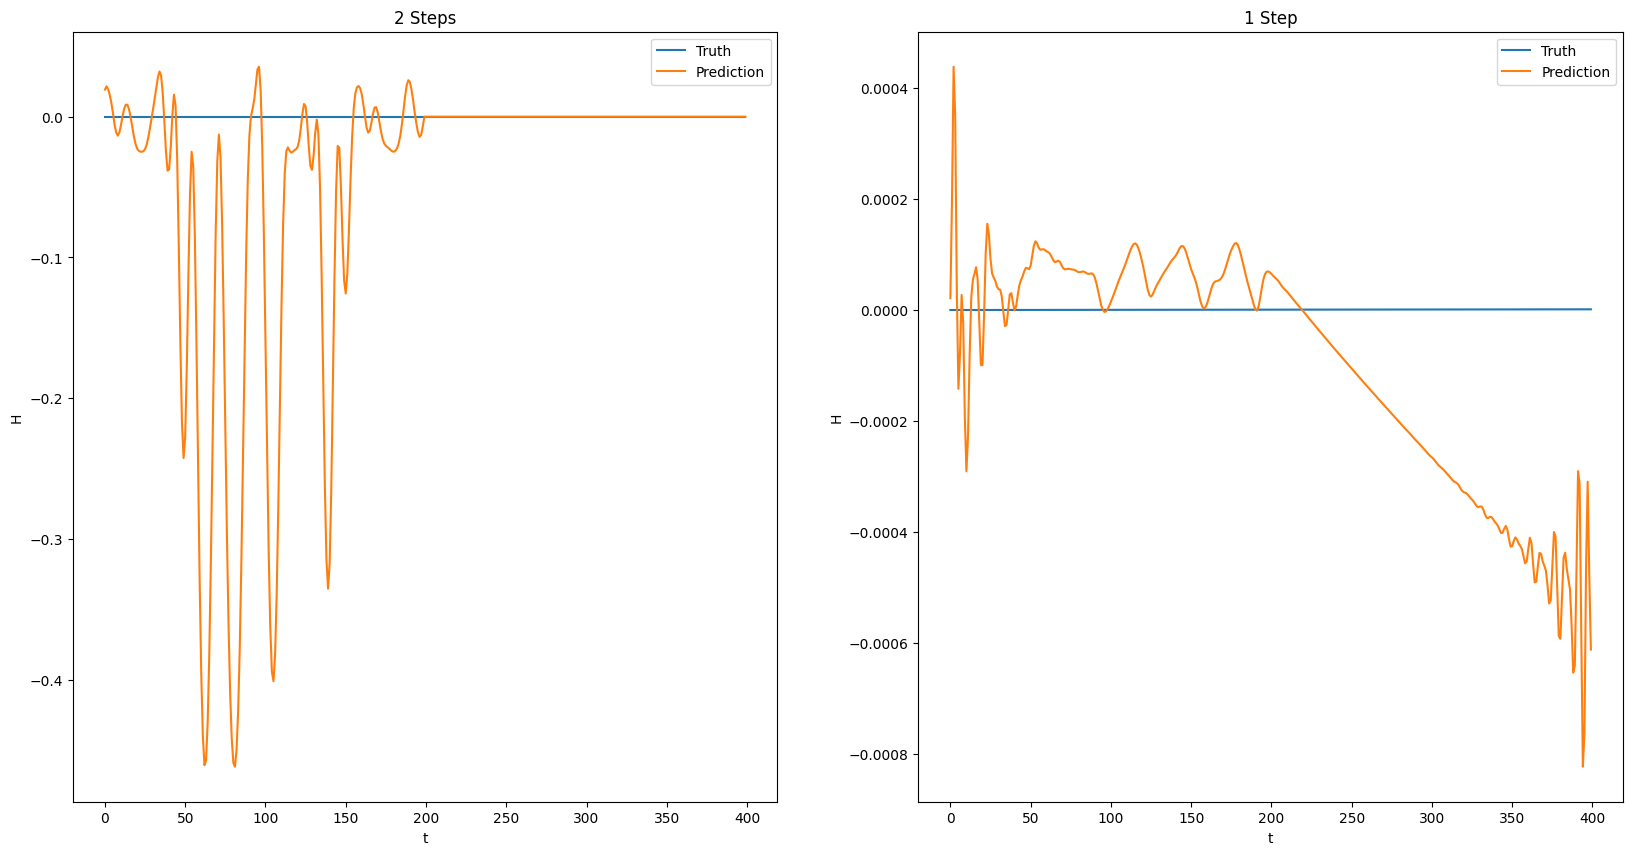

In [26]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.8-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.9$

2 Step RE (Interpolation) = 1.0000
2 Step RE (Extrapolation) = 0.6089
2 Step RE (Total) = 0.8045

1 Step RE (Interpolation) = 0.9943
1 Step RE (Extrapolation) = 0.9999
1 Step RE (Total) = 0.9971
2 Step MSE (Interpolation) = 5.96224E-02
2 Step MSE (Extrapolation) = 1.43629E-13
2 Step MSE (Total) = 2.98112E-02

1 Step MSE (Interpolation) = 4.30729E-08
1 Step MSE (Extrapolation) = 1.51426E-06
1 Step MSE (Total) = 7.78669E-07


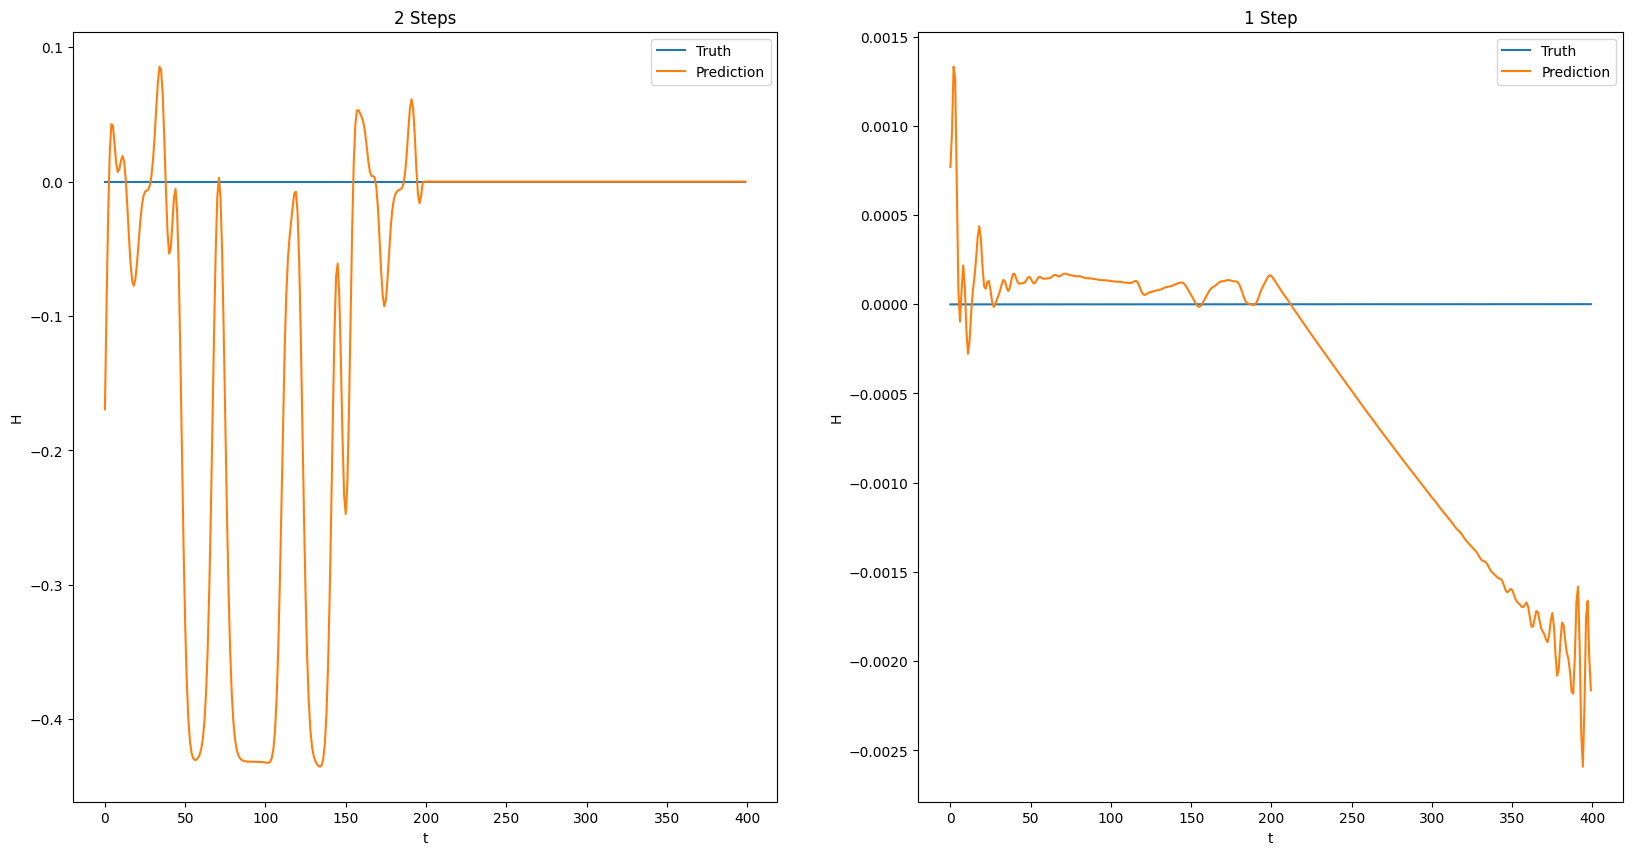

In [27]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.9-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

# Symplicitc Integeration
                                                                           
When both methods go through symplectic integeration afterwards, the extrapolation for H is generally consistent across the two methods (no energy loss in the 1-step results), the main difference happens in the interpolation period where the 2-step is generally performing worse due to the sparsity in the data. Hence, REs for 1-step is lower than of those of the 2-steps. However, all the REs remain high due to the zero problem we mentioned before.

In [28]:
DATA_DIR = "/home/ubuntu/CGC/200-separable-polynomial-with-data-adjusted-and-symplictic/ms/"

## $\alpha = 0.0$

2 Step RE (Interpolation) = 0.9793
2 Step RE (Extrapolation) = 0.9991
2 Step RE (Total) = 0.9892

1 Step RE (Interpolation) = 0.9793
1 Step RE (Extrapolation) = 0.9991
1 Step RE (Total) = 0.9892
2 Step MSE (Interpolation) = 1.04583E-09
2 Step MSE (Extrapolation) = 9.30695E-06
2 Step MSE (Total) = 4.65400E-06

1 Step MSE (Interpolation) = 1.04583E-09
1 Step MSE (Extrapolation) = 9.30695E-06
1 Step MSE (Total) = 4.65400E-06


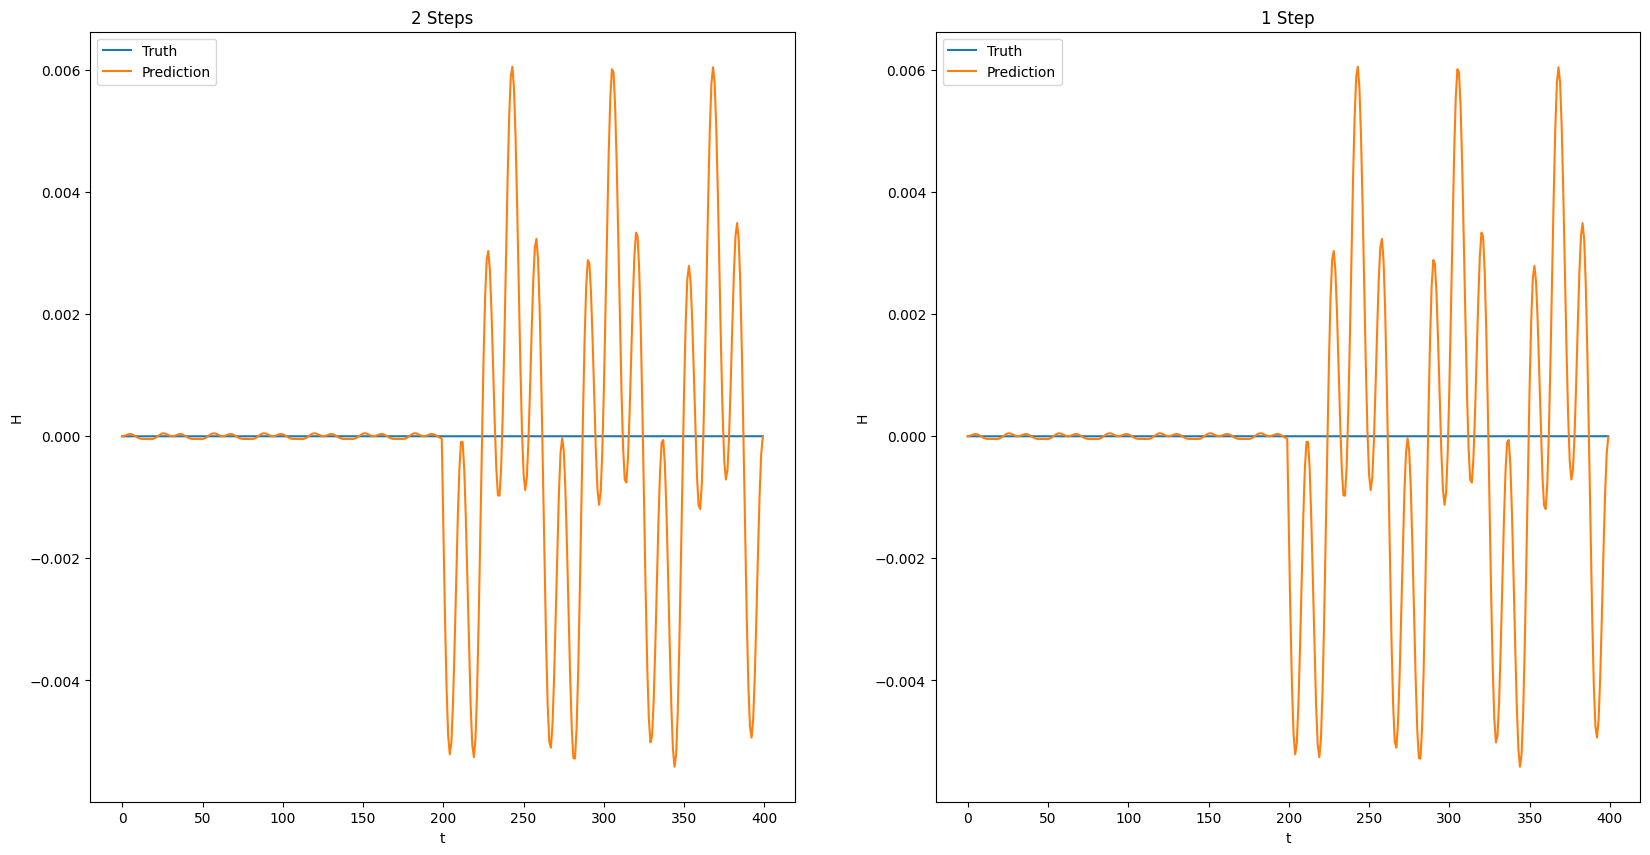

In [29]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.0-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.5$

2 Step RE (Interpolation) = 0.9970
2 Step RE (Extrapolation) = 0.9997
2 Step RE (Total) = 0.9984

1 Step RE (Interpolation) = 0.9757
1 Step RE (Extrapolation) = 0.9988
1 Step RE (Total) = 0.9873
2 Step MSE (Interpolation) = 3.00456E-07
2 Step MSE (Extrapolation) = 9.50795E-06
2 Step MSE (Total) = 4.90421E-06

1 Step MSE (Interpolation) = 3.84259E-09
1 Step MSE (Extrapolation) = 9.30959E-06
1 Step MSE (Total) = 4.65672E-06


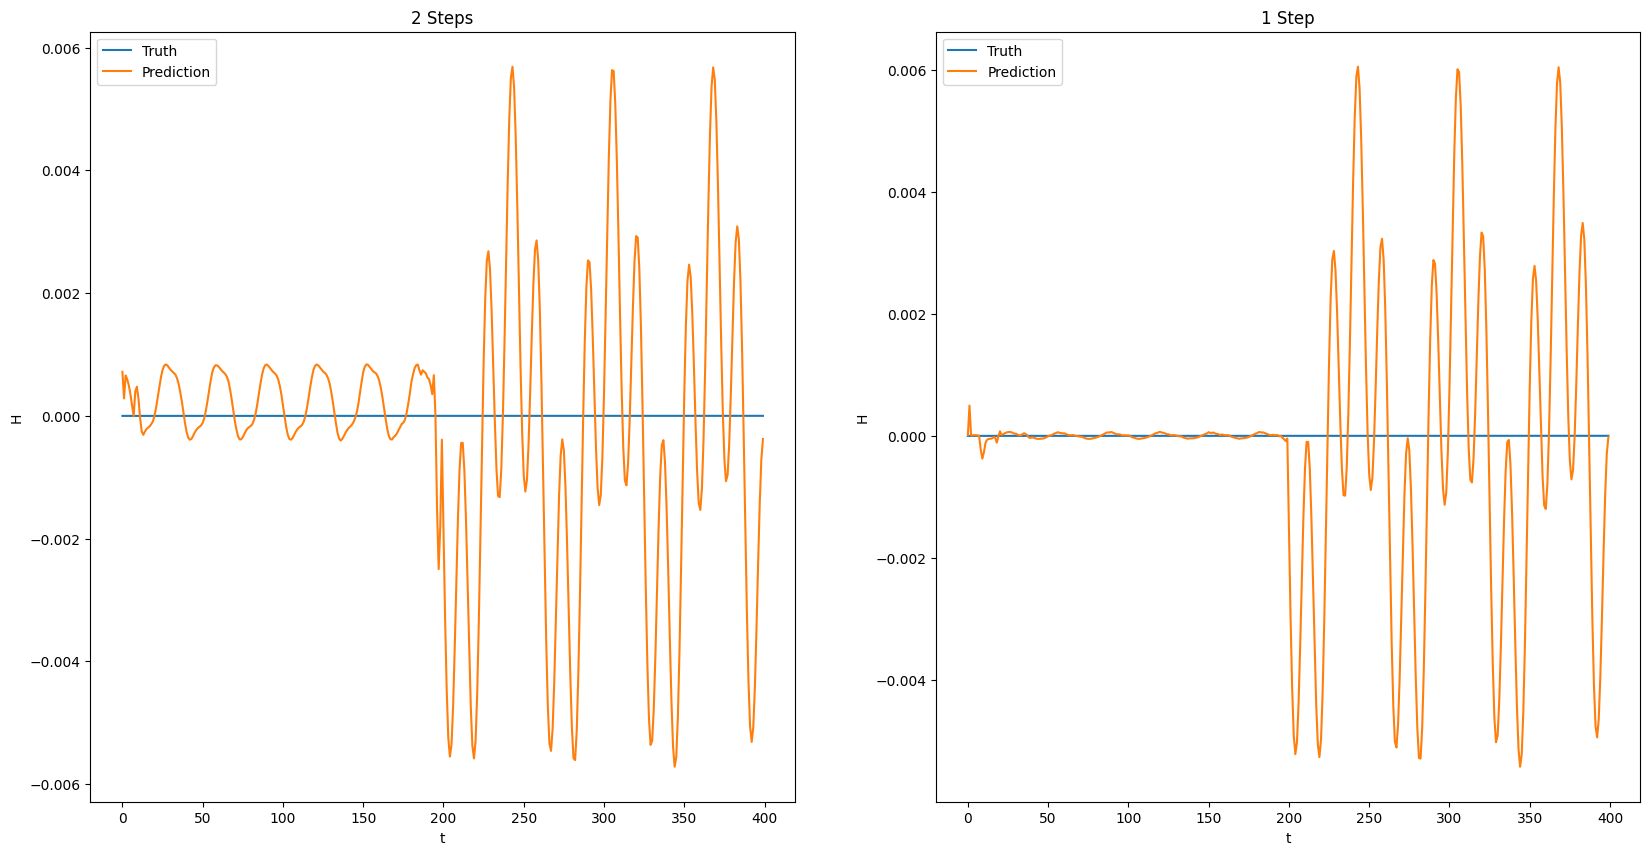

In [30]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.5-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.6$

2 Step RE (Interpolation) = 0.9986
2 Step RE (Extrapolation) = 0.9995
2 Step RE (Total) = 0.9990

1 Step RE (Interpolation) = 0.9844
1 Step RE (Extrapolation) = 0.9996
1 Step RE (Total) = 0.9920
2 Step MSE (Interpolation) = 2.42732E-05
2 Step MSE (Extrapolation) = 9.36634E-06
2 Step MSE (Total) = 1.68198E-05

1 Step MSE (Interpolation) = 3.38275E-09
1 Step MSE (Extrapolation) = 9.31686E-06
1 Step MSE (Total) = 4.66012E-06


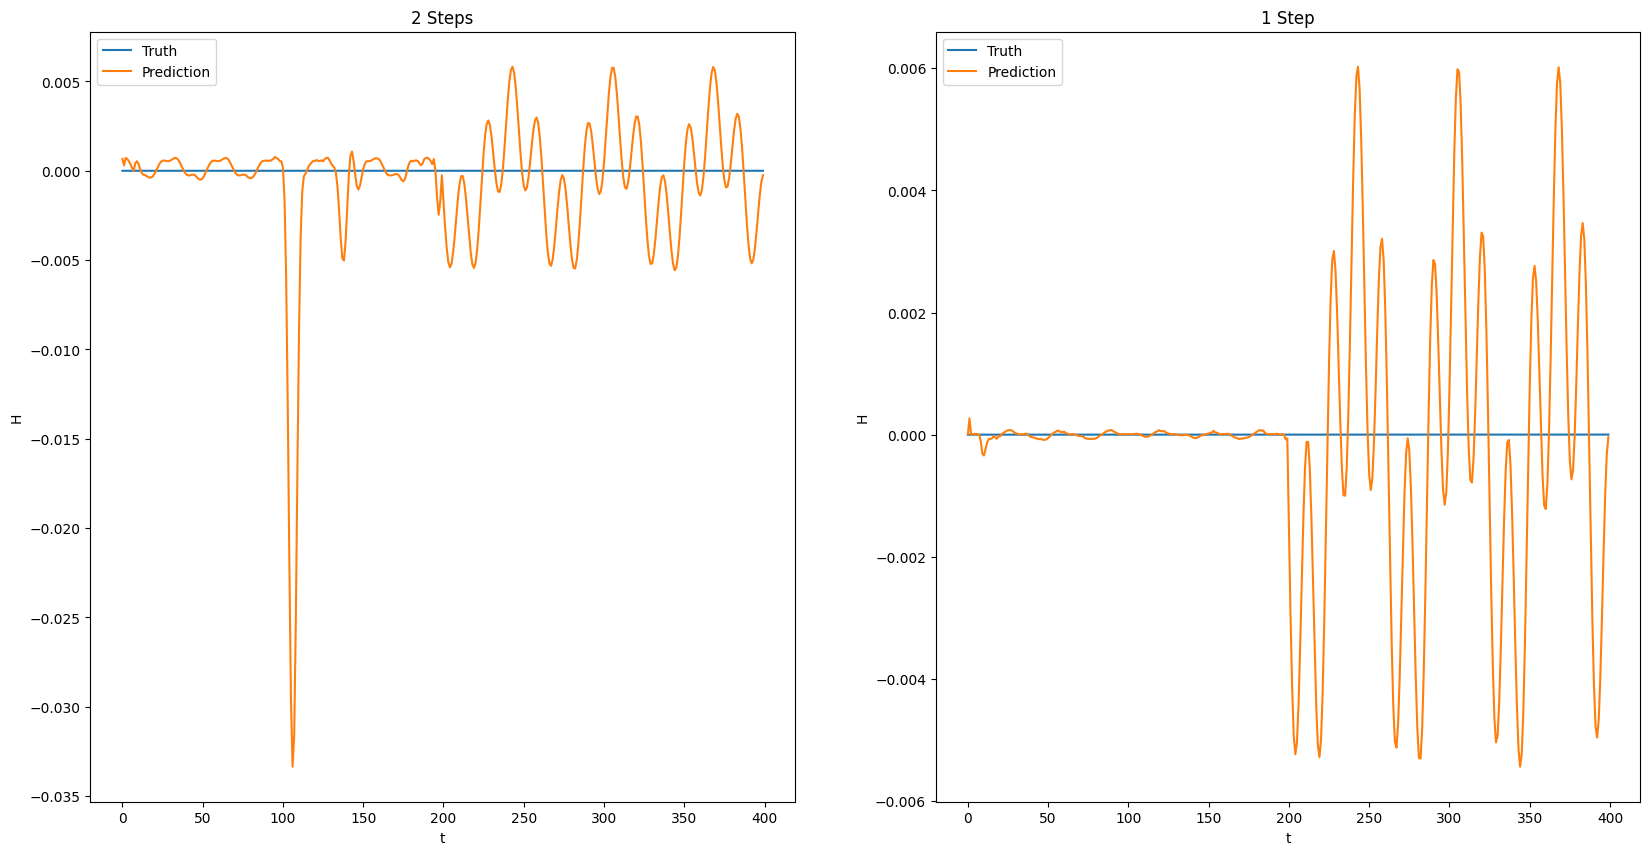

In [12]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.6-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.7$

2 Step RE (Interpolation) = 0.9999
2 Step RE (Extrapolation) = 0.9995
2 Step RE (Total) = 0.9997

1 Step RE (Interpolation) = 0.9571
1 Step RE (Extrapolation) = 0.9994
1 Step RE (Total) = 0.9782
2 Step MSE (Interpolation) = 1.65917E-03
2 Step MSE (Extrapolation) = 9.35964E-06
2 Step MSE (Total) = 8.34267E-04

1 Step MSE (Interpolation) = 5.40746E-09
1 Step MSE (Extrapolation) = 9.30611E-06
1 Step MSE (Total) = 4.65576E-06


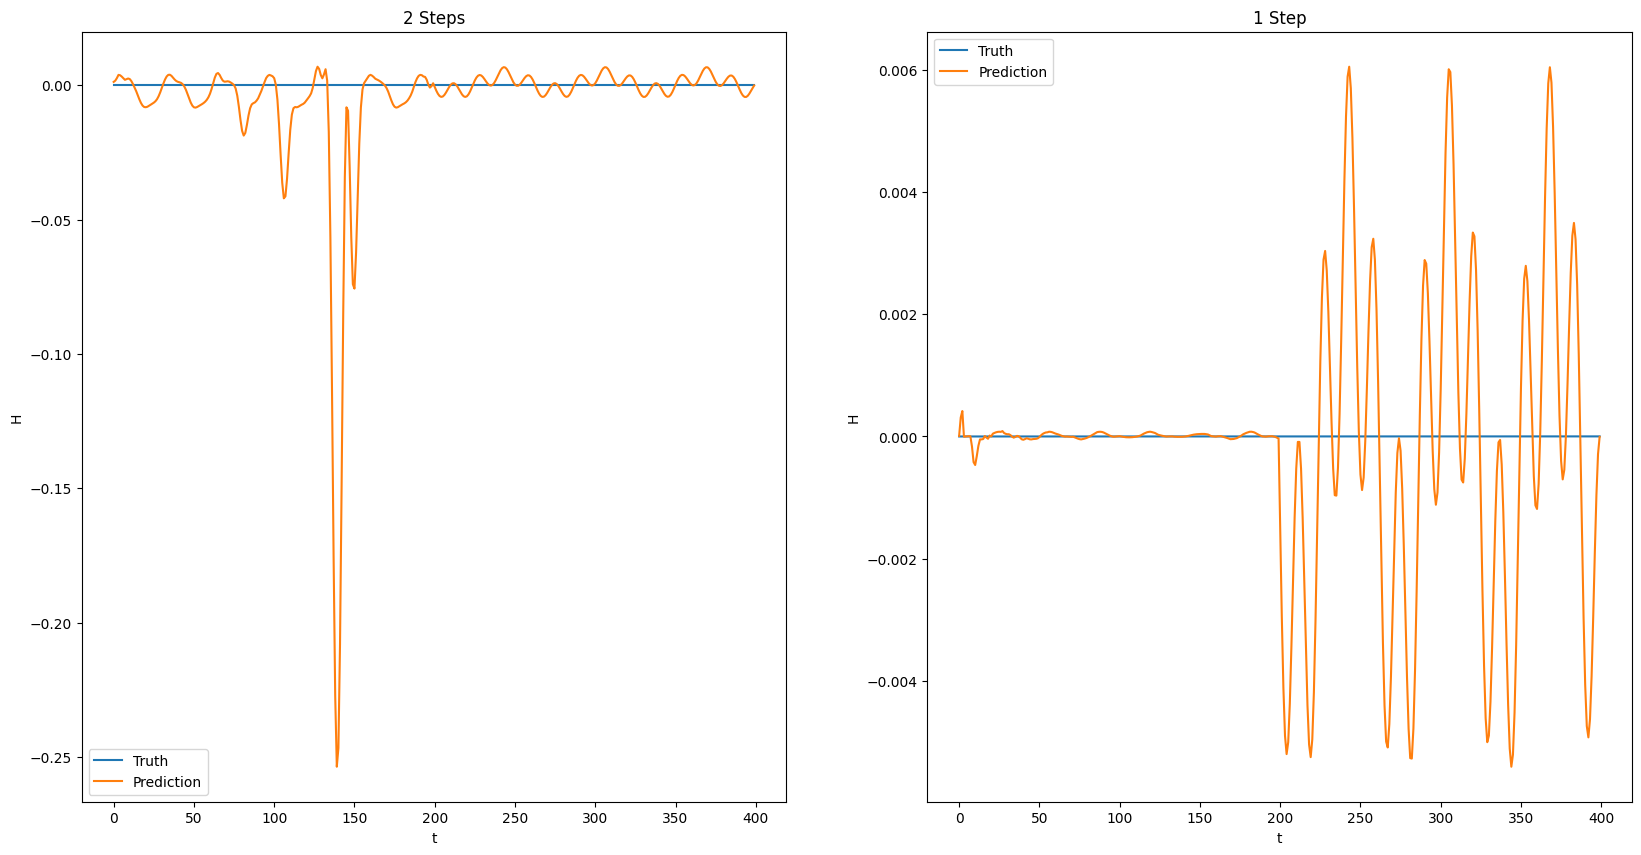

In [13]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.7-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.8$

2 Step RE (Interpolation) = 1.0000
2 Step RE (Extrapolation) = 0.9949
2 Step RE (Total) = 0.9974

1 Step RE (Interpolation) = 0.9677
1 Step RE (Extrapolation) = 0.9989
1 Step RE (Total) = 0.9833
2 Step MSE (Interpolation) = 2.58715E-02
2 Step MSE (Extrapolation) = 8.03310E-06
2 Step MSE (Total) = 1.29398E-02

1 Step MSE (Interpolation) = 6.14332E-09
1 Step MSE (Extrapolation) = 9.30103E-06
1 Step MSE (Total) = 4.65359E-06


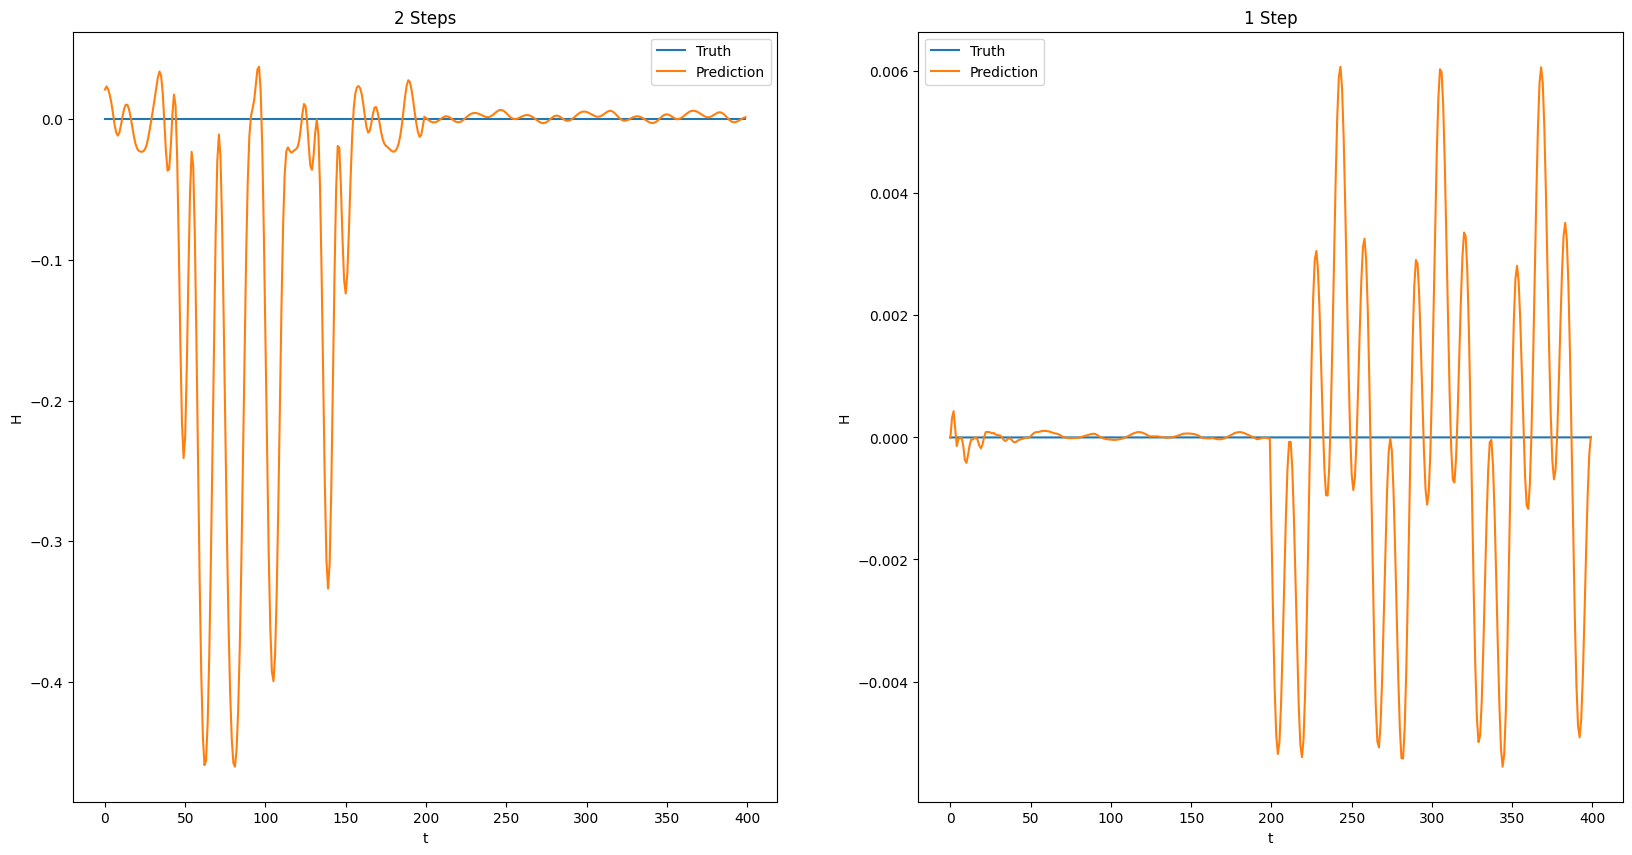

In [14]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.8-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)

## $\alpha = 0.9$

2 Step RE (Interpolation) = 1.0000
2 Step RE (Extrapolation) = 0.9990
2 Step RE (Total) = 0.9995

1 Step RE (Interpolation) = 0.9797
1 Step RE (Extrapolation) = 0.9952
1 Step RE (Total) = 0.9874
2 Step MSE (Interpolation) = 5.90466E-02
2 Step MSE (Extrapolation) = 6.18311E-06
2 Step MSE (Total) = 2.95264E-02

1 Step MSE (Interpolation) = 2.76935E-08
1 Step MSE (Extrapolation) = 9.29215E-06
1 Step MSE (Total) = 4.65992E-06


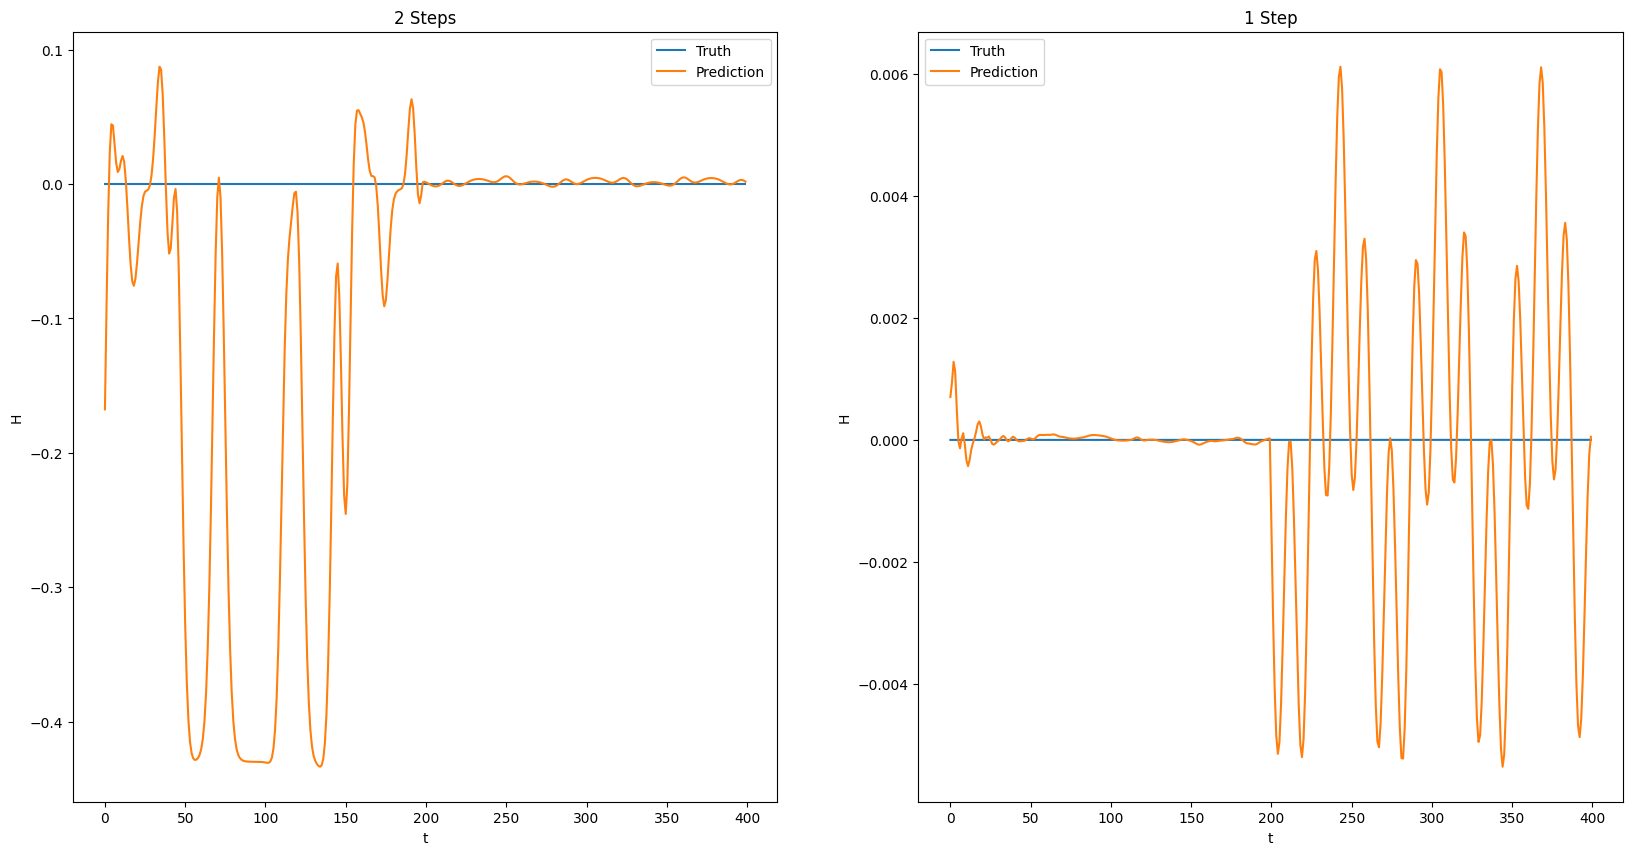

In [31]:
H, H_2s, H_1s = get_H_data(DATA_DIR + "0.9-best-data/")
plot_Hs_minus_median(H, H_2s, H_1s)
calculate_errors(H, H_2s, H_1s)